# Assignment 1 – Data Preparation for Bank Marketing Dataset

**Student:** Tatiana Quinn  
**Course:** BCSAI Machine Learning Foundations  

**GitHub repository for this notebook:**  
[ML-fundamentals-2026](https://github.com/TatianaQuinnIE/ML-fundamentals-2026)

## Introduction

In this assignment I had to carry out **data preparation and feature engineering** for the UCI Bank Marketing dataset: a real-world dataset from a Portuguese bank’s telemarketing campaigns. The goal was not to build an accurate model, but to prepare the data correctly so that a reliable model *could* be built in the future. I had to explore the data, handle explicit and implicit missing values, encode categorical variables, scale numerical features, split the data into training/validation/test sets with stratification, address class imbalance, and perform feature selection while avoiding data leakage. At the end, I had to train a simple Logistic Regression model as a sanity check.

I worked through these steps in the following pipeline order, which I chose to avoid data leakage: 

1. **Load the dataset**.
2. **Identify the prediction target (`y`)**.
3. **Explore the data (EDA)** to understand variable types, distributions, and potential issues (e.g. `duration`).
4. **Split into training, validation, and test sets**, so that only the training set is used to learn preprocessing steps.
5. **Encode categorical variables**, fitting encoders on the training set only.
6. **Scale numerical features**, fitting scalers on the training set only.
7. **Perform feature selection** using only the training set.
8. **Address class imbalance** by resampling the training data.
9. **Train and evaluate a Logistic Regression model** on the processed data.

An example of incorrect ordering would have been to fit the scaler or one-hot encoder on the full dataset before splitting. This would have leaked information such as validation/test means or category frequencies into the preprocessing step, which would have made validation performance look better than it should.

Below I walk through what I did in each step and why.

### Step 1 - Loading the data

First, I imported all the libraries I needed for the assignment (`pandas` and `numpy` for data handling, `matplotlib` and `seaborn` for plots, `sklearn` for preprocessing and the logistic regression model, and `RandomOverSampler` from `imblearn` for handling class imbalance later) and loaded the `bank-additional.csv` dataset into a Pandas DataFrame. Note that you should update `data_path` to point to where you saved `bank-additional.csv` in order to run this notebook. The file is semicolon-separated, so I passed `sep=";"` to `read_csv`. I confirmed that the data loaded correctly by displaying the first five rows with `df.head()`.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import RandomOverSampler

pd.set_option("display.max_columns", None)

data_path = "/Users/tatianaquinn/Downloads/archive/bank-additional.csv"
df = pd.read_csv(data_path, sep=";")

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,487,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,346,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,227,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,17,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,58,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


### Step 2 - Identifying the prediction target (`y`)

The problem statement of this assignment was to predict whether a client would subscribe to a term deposit given client and campaign information available at contact time. So, the target had to be a variable that (1) directly represented “subscribed or not” in this campaign, and (2) was not itself an input that would be used when making the prediction. I found that the column `y` takes the values "yes" and "no" and, from the dataset description, corresponds exactly to whether the client subscribed to a term deposit after the contact in that row. 

I also checked other columns that might look like outcomes: 
- `poutcome` describes the result of a previous marketing campaign (e.g. `success`, `failure`, or `“nonexistent”` if there was no prior contact), which is useful as a feature (past behavior may help predict current behavior), but it is not the outcome we are asked to predict. So, I decided this is an input, not the target. 
- `duration` is the length of the current call in seconds, which is something that can only be known after the call ends and would therefore not be available at prediction time. Using it as a feature would create temporal data leakage, so I decided to exclude it from the features later.

I therefore chose `y` as the prediction target and decided I would later exclude `duration` from the features. The code below prints the dataset shape, columns, and the target distribution; from which I noticed that the target was clearly imbalanced (most clients "no", few "yes"), and I noted that I would need to address this later.

In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nTarget distribution (absolute):")
print(df["y"].value_counts())
print("\nTarget distribution (relative):")
print(df["y"].value_counts(normalize=True))

Shape: (4119, 21)

Columns:
Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

Target distribution (absolute):
y
no     3668
yes     451
Name: count, dtype: int64

Target distribution (relative):
y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64


### Step 3 - Exploring the data (EDA)

I then needed to understand the structure of the data and where missing or special values might appear. I separated the columns into numeric and categorical using `select_dtypes`, so that I could apply the appropriate preprocessing later (for example, encoding for categorical variables and scaling for numerical ones). Numeric columns were those with `int64` or `float64` dtypes (such as `age`, `duration`, `campaign`, `pdays`, and the macroeconomic indicators), and categorical columns were those with `object` dtype (such as `job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `day_of_week`, `poutcome`, and `y`). I printed both lists so I could see exactly which variables I would treat as numeric and which as categorical in later steps.

Then, I checked for explicit missing values by computing `df.isna().sum()` per column; this showed that no cells were stored as `NaN`. I also looked for implicit missing values: for the columns that contain the placeholder category `"unknown"` (`job`, `education`, `default`, `housing`, and `loan`), I printed value counts so I could see how often `"unknown"` appeared, since those act as missingness even though they are not `NaN`. I also printed value counts for `poutcome` to understand how often each previous-campaign outcome occurred. Finally, I inspected the variable `pdays`, because in this dataset the value `999` is used as a sentinel meaning “no previous contact”. I computed the proportion of rows where `pdays` equals `999` (about 96%) so I knew how widespread this sentinel was and could plan how to handle it. Based on this exploration, I made two modelling decisions: I would treat `"unknown"` as a separate category so the model could learn whether unknown status is informative, and I would keep `pdays` as a numerical variable including the sentinel value so the model could learn that `999` indicates no previous contact.

To support the exploration with visual summaries, I produced two figures as required by the assignment. In the first figure I plotted the distribution of two numerical variables, `age` and `euribor3m`, using histograms with a kernel density estimate (KDE) so I could see the shape and spread of each variable. I observed that `age` was right‑skewed, with most clients clustered in middle age and relatively few very young or very old clients, and that `euribor3m` showed a few distinct modes and a wide range of interest rates rather than a single tight peak. In the second figure I plotted two categorical variables, `job` and `education`, using count plots (bar charts of category counts) ordered by frequency, with axis labels rotated to avoid overlap. From these plots I saw that both `job` and `education` had many categories, some of which were quite rare, and that `"unknown"` appeared but did not dominate any column. This confirmed that one‑hot encoding would substantially increase dimensionality but that no single rare category would overwhelm the counts.

In [3]:
# Basic summary statistics (numeric variables)
display(df.describe())

# Summary statistics for categorical variables
display(df.describe(include=["object", "string"]))

# Numeric vs categorical
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numeric columns:\n", numeric_cols)
print("\nCategorical columns:\n", categorical_cols)

# Explicit missing values
print("\nMissing values per column:")
print(df.isna().sum())

# Implicit missing values: 'unknown' categories
for col in ["job", "education", "default", "housing", "loan", "poutcome"]:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())

# Sentinel code for pdays
print("\nProportion of pdays == 999 (sentinel for no previous contact):")
print((df["pdays"] == 999).mean())

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,1012,2509,1264,3315,2175,3349,2652,1378,860,3523,3668


Numeric columns:
 ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical columns:
 ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

Missing values per column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Value counts for job:
job
admin.           1012
blue-collar       884
technician        691
services          393
management        324
retired           166
self-employed     159
entrepreneur      148
unemployed        111
housemaid         110
stude

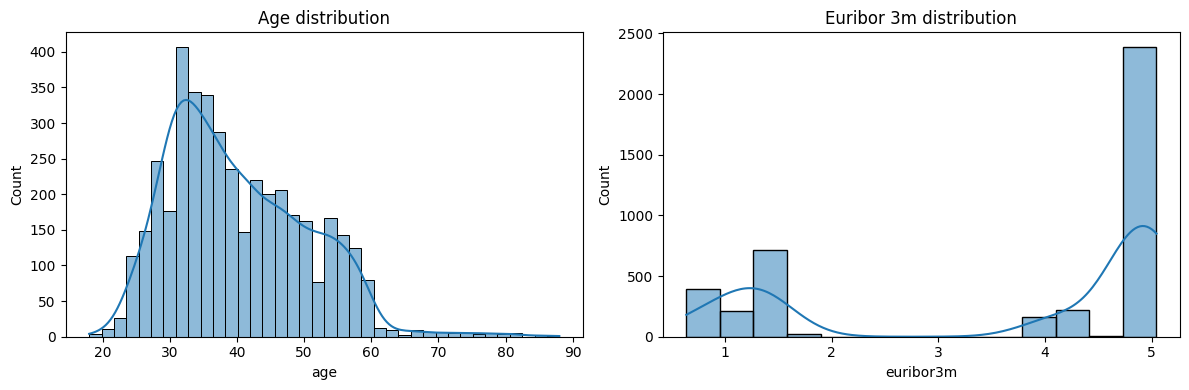

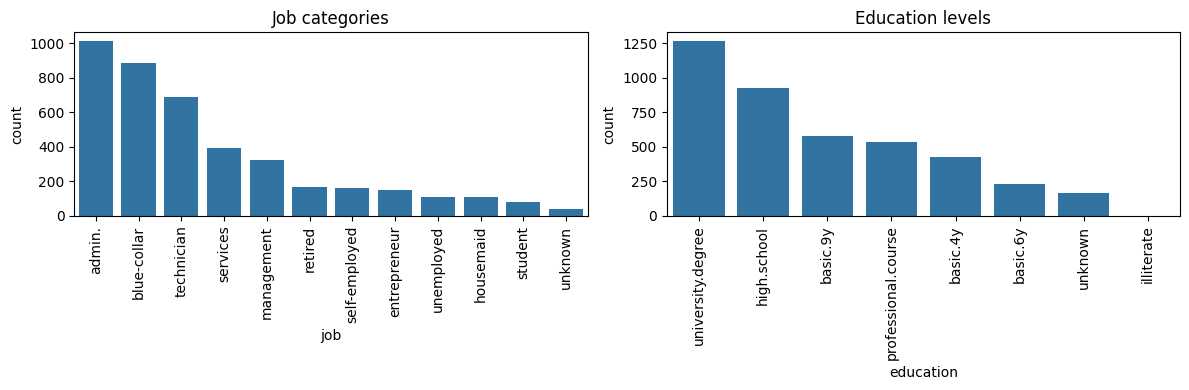

In [4]:
# Two numerical variables: age and euribor3m
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df["age"], kde=True)
plt.title("Age distribution")

plt.subplot(1, 2, 2)
sns.histplot(df["euribor3m"], kde=True)
plt.title("Euribor 3m distribution")
plt.tight_layout()
plt.show()

# Two categorical variables: job and education
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.countplot(x="job", data=df, order=df["job"].value_counts().index)
plt.xticks(rotation=90)
plt.title("Job categories")

plt.subplot(1, 2, 2)
sns.countplot(x="education", data=df, order=df["education"].value_counts().index)
plt.xticks(rotation=90)
plt.title("Education levels")
plt.tight_layout()
plt.show()

### Step 4 - Splitting into training, validation, and test sets

After exploring the data, I split it into three separate parts: 60% training, 20% validation, and 20% test. I chose these proportions because the training set needed to be the largest portion in order to fit both the preprocessing steps (encoding and scaling) and the Logistic Regression model, while still leaving enough data for a reliable validation check and a final held‑out test set. Using 20% each for validation and test gave me enough positive examples (the target is imbalanced) to make precision/recall estimates more stable than if the sets were very small.

To implement this, I first separated features and target by creating `X` (all columns except `y`) and `y` (the target column). At this point, I also dropped the column `duration` from `X` to avoid data leakage (see Step 2), because call duration would not be available at prediction time. I then performed the split in two stages: in the first call to `train_test_split`, I split the full dataset into a training set and a temporary set (`temp`) using `test_size=0.4` (so 60% training, 40% temporary). In the second call, I split `temp` into validation and test sets of equal size using `test_size=0.5`, which produced 20% validation and 20% test overall. In both splits I used `stratify` on `y` so that each set preserved the original class distribution (about 89% `"no"` and 11% `"yes"`), since without stratification the smaller splits could end up with too few positive examples.

In [5]:
# Separate features and target
X = df.drop(columns=["y"])
y = df["y"]

# Drop 'duration' to avoid leakage (not available at prediction time)
X = X.drop(columns=["duration"])

# First split: train vs temp (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,      # 60% train, 40% temp
    stratify=y,
    random_state=42
)

# Second split: temp into val and test (each 20% of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,      # half of 40% -> 20% val, 20% test
    stratify=y_temp,
    random_state=42
)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))
print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Train size: 2471
Validation size: 824
Test size: 824

Train target distribution:
y
no     0.890328
yes    0.109672
Name: proportion, dtype: float64

Validation target distribution:
y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64

Test target distribution:
y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64


### Step 5 – Encoding categorical variables

Next, I had to turn the categorical features into numerical form for the Logistic Regression model to use. I recomputed the lists of categorical and numerical columns from `X` using `select_dtypes()` so that they no longer included `y` and `duration` (dropped in Step 4). While most of the categorical variables are nominal, `education` is ordinal (levels correspond to increasing education), but I still used one-hot encoding for `education`, so that the model coefficients would be easier to interpret. 

I used scikit-learn’s `OneHotEncoder` with `handle_unknown="ignore"` so that if the validation or test set contained a category not seen in the training set, that value would be encoded as all zeros rather than causing an error. I kept `"unknown"` as a normal category, as decided in the EDA (see Step 3), so the model could use unknown status as potential signal.

One-hot encoding changes the feature space in important ways. It increases the dimensionality of the dataset by creating one binary indicator feature per category level, which is why variables such as `job` and `education` (with many levels) lead to a larger number of input features. It also affects interpretability: each one-hot coefficient corresponds to the association between a specific category and the prediction (relative to the reference category), rather than mixing all categories into a single numeric code. Finally, one-hot encoding increases the expressiveness of a linear model by allowing different categories to shift the decision boundary independently, whereas an integer encoding would incorrectly impose a monotonic relationship where “higher-coded” categories always push the prediction in the same direction. The code below prints the recomputed numeric and categorical column lists; the encoding itself is then applied in the preprocessor in the next step.

In [6]:
# Recompute numeric/categorical columns based on X (with duration removed)
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numeric columns:\n", numeric_cols)
print("\nCategorical columns:\n", categorical_cols)

Numeric columns:
 ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical columns:
 ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


### Step 6 – Scaling numerical features

I then applied standardisation, since Logistic Regression is trained with gradient-based optimisation and tends to behave better when numerical features are on a similar scale. To do this, I used `StandardScaler` so that each numerical feature has zero mean and unit variance on the training set. This helps the optimiser converge more reliably, because features with very different magnitudes can cause the gradient updates to be dominated by large-scale variables.

Scaling also affects how the model coefficients and regularisation behave. After standardisation, the coefficients become more comparable across numerical features, because a one‑unit change corresponds to a change of one standard deviation rather than one unit in the original measurement scale. This also makes the effect of the regularisation penalty more interpretable: with unscaled features, regularisation can shrink coefficients unevenly simply because some variables are measured on much larger numeric scales, not because they are more important. Standardising reduces that problem and makes the penalty act more consistently across numerical inputs.

I combined the numerical scaling and the categorical encoding in a single `ColumnTransformer`: one branch for the numeric columns with `StandardScaler`, and one for the categorical columns with the `OneHotEncoder` from Step 5. The transformer was fitted only on the training data and then applied to the validation and test sets, which avoided leaking information from those sets into the preprocessing stage.

In [7]:
# Preprocess: one-hot encode categoricals, scale numericals
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

# Fit preprocessor on training data only
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (2471, 62)
Processed validation shape: (824, 62)
Processed test shape: (824, 62)


### Step 7 - Performing feature selection

Before training the model, I checked whether any numerical features should be removed on the grounds of very low variance or very high correlation. I performed these checks using the training set only (`X_train[numeric_cols]`) so that validation and test data would not influence which features were kept. If I performed feature selection on the full dataset before splitting, it would leak information from validation/test into the training pipeline and bias model evaluation.

For the variance check, I computed the variance of each numerical feature on the training set with `train_num.var(numeric_only=True)` and sorted the results to see which features had the smallest spread. As a rule of thumb, I would consider dropping a numerical feature if its variance were extremely close to zero (i.e. almost constant), because it would contribute little information to a linear model. In this dataset, none of the numerical features appeared near-constant (the smallest variances were still clearly above zero, e.g. for `previous` and `cons.price.idx`), so I kept them all.

For the correlation check, I computed the correlation matrix of the numerical training features with `train_num.corr(numeric_only=True)` and inspected the absolute correlations. I used a threshold such as `|r| > 0.90` to flag very strongly correlated feature pairs. Some macroeconomic variables (such as `emp.var.rate`, `euribor3m`, and `nr.employed`) were strongly correlated, but I chose to keep them because removing them could discard useful signal.

In [8]:
# Feature selection checks (training set only) — numeric features only
train_num = X_train[numeric_cols].copy()

# Low-variance check
variances = train_num.var(numeric_only=True).sort_values()
variances

previous              0.320324
cons.price.idx        0.343885
emp.var.rate          2.457339
euribor3m             3.038669
campaign              7.183459
cons.conf.idx        21.749100
age                 106.440729
nr.employed        5481.162130
pdays             39423.819334
dtype: float64

In [9]:
# Correlation check (training set only)
corr = train_num.corr(numeric_only=True).abs()
corr

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,0.009352,0.052078,0.033627,0.010362,0.008347,0.117791,0.003252,0.033675
campaign,0.009352,1.000000,0.070989,0.104890,0.192923,0.145004,0.017746,0.176367,0.176557
pdays,0.052078,0.070989,1.000000,0.601067,0.282549,0.066999,0.108763,0.312390,0.394334
previous,0.033627,0.104890,0.601067,1.000000,0.428931,0.183358,0.021387,0.469319,0.520717
emp.var.rate,0.010362,0.192923,0.282549,0.428931,1.000000,0.757662,0.178391,0.970013,0.896018
cons.price.idx,0.008347,0.145004,0.066999,0.183358,0.757662,1.000000,0.029163,0.656884,0.470515
cons.conf.idx,0.117791,0.017746,0.108763,0.021387,0.178391,0.029163,1.000000,0.264169,0.096543
euribor3m,0.003252,0.176367,0.312390,0.469319,0.970013,0.656884,0.264169,1.000000,0.941699
nr.employed,0.033675,0.176557,0.394334,0.520717,0.896018,0.470515,0.096543,0.941699,1.000000


### Step 8 – Addressing class imbalance

To reduce the impact of the class imbalance (see Step 2) on the learning algorithm, I applied random oversampling to the training set only using `RandomOverSampler` from `imblearn`. I did this by creating a `RandomOverSampler` with `random_state=42` for reproducibility, calling `fit_resample` on the preprocessed training features and training labels (`X_train_processed` and `y_train`), and then printing the original and resampled class counts to confirm that the training set was balanced before fitting the model. I left the validation and test sets unchanged so that they keep the original class distribution and give a realistic estimate of performance on unseen, imbalanced data.

If I had applied oversampling before splitting the dataset, I would have risked copying the same minority-class observations into multiple splits (for example, the same duplicated row could appear in both training and validation). This would have contaminated evaluation because the model could have effectively “seen” examples in validation/test that were duplicated from training, leading to overly optimistic metrics.

It should also be noted that, with an imbalanced target, accuracy can be misleading because a model can achieve high accuracy by mostly predicting the majority class. Precision and recall for the positive class `"yes"` are therefore important: oversampling typically makes the model predict more positives, which can increase recall but may reduce precision and sometimes lowers overall accuracy.

In [10]:
# Random oversampling on the processed training set
ros = RandomOverSampler(random_state=42)

X_train_resampled, y_train_resampled = ros.fit_resample(X_train_processed, y_train)

print("Original training class distribution:")
print(y_train.value_counts())

print("\nResampled training class distribution:")
print(y_train_resampled.value_counts())

Original training class distribution:
y
no     2200
yes     271
Name: count, dtype: int64

Resampled training class distribution:
y
no     2200
yes    2200
Name: count, dtype: int64


### Step 9 – Training and evaluating a Logistic Regression model

I trained a Logistic Regression model on the resampled, preprocessed training data as a sanity check that the pipeline works and to predict whether a client subscribes to a term deposit. I used `LogisticRegression` with `max_iter=1000` and `random_state=42` so that the solver had enough iterations to converge and results were reproducible. I then evaluated the model on the validation set (not the test set, which I kept for a final unbiased estimate). I obtained predictions with `log_reg.predict(X_val_processed)`, since the validation set had already been transformed by the preprocessor fitted on the training set.

I computed accuracy, precision, and recall for `"yes"` using `accuracy_score`, `precision_score`, and `recall_score` with `pos_label="yes"`. I also computed a Zero Rule baseline that always predicts the majority class from the training set (`y_train.value_counts().idxmax()`) and compared its accuracy on the validation set to the model’s accuracy. In my results, the Zero Rule baseline achieved higher accuracy, which is expected because the dataset is strongly imbalanced and always predicting `"no"` is hard to beat on accuracy alone. However, after oversampling the Logistic Regression model predicted more `"yes"`, which increased recall for the positive class at the cost of lower precision and lower overall accuracy. 

Finally, I plotted a confusion matrix with `ConfusionMatrixDisplay.from_predictions` to show the counts of true positives, true negatives, false positives, and false negatives on the validation set.

In [11]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_resampled, y_train_resampled)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [12]:
# Predictions on validation set
y_val_pred = log_reg.predict(X_val_processed)

accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred, pos_label="yes")
recall = recall_score(y_val, y_val_pred, pos_label="yes")

print("Validation Accuracy:", accuracy)
print("Validation Precision (yes):", precision)
print("Validation Recall (yes):", recall)

# Zero Rule baseline: always predict the majority class from training set
majority_class = y_train.value_counts().idxmax()
y_val_baseline = np.full_like(y_val, fill_value=majority_class)

zero_rule_accuracy = accuracy_score(y_val, y_val_baseline)
print("\nZero Rule baseline accuracy (always predict", majority_class, "):", zero_rule_accuracy)

Validation Accuracy: 0.8288834951456311
Validation Precision (yes): 0.33962264150943394
Validation Recall (yes): 0.6

Zero Rule baseline accuracy (always predict no ): 0.8907766990291263


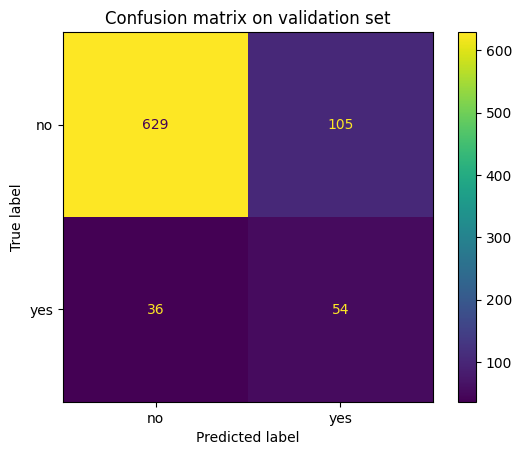

In [13]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred)
plt.title("Confusion matrix on validation set")
plt.show()